## task info

Use Fetch California Housing from sklearn with cleaning, EDA and ML model to reach above 61% accuracy

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression


## Load California Housing Dataset

In [2]:
california = fetch_california_housing(as_frame=True)
df = california.frame

df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Data Cleaning

In [3]:
df.describe()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [4]:
# Check missing values
df.isnull().sum()


MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Dataset has no missing values

In [5]:
# Check duplicates
df.duplicated().sum()


np.int64(0)

No duplicates

# Exploratory Data Analysis (EDA)

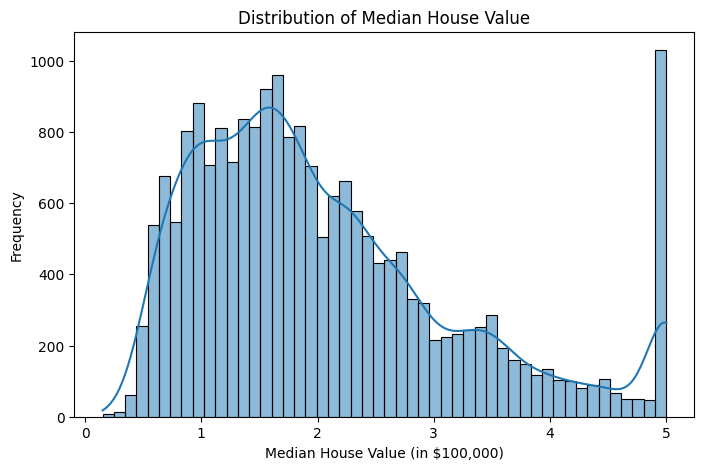

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(df['MedHouseVal'], bins=50, kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value (in $100,000)')
plt.ylabel('Frequency')
plt.show()

> A histogram shows the distribution of median house values, providing insights into the price range of houses in California.


Scatter plot of median income vs. median house value

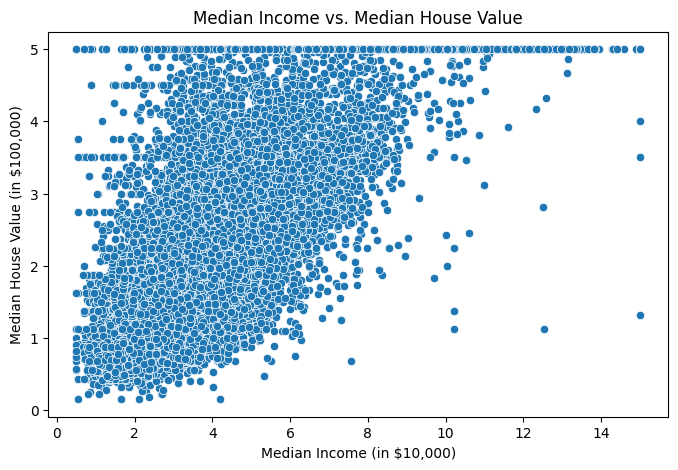

In [7]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='MedInc', y='MedHouseVal', data=df)
plt.title('Median Income vs. Median House Value')
plt.xlabel('Median Income (in $10,000)')
plt.ylabel('Median House Value (in $100,000)')
plt.show()



> A scatter plot shows the relationship between median income and house value, indicating a positive correlation.



Correlation matrix heatmap

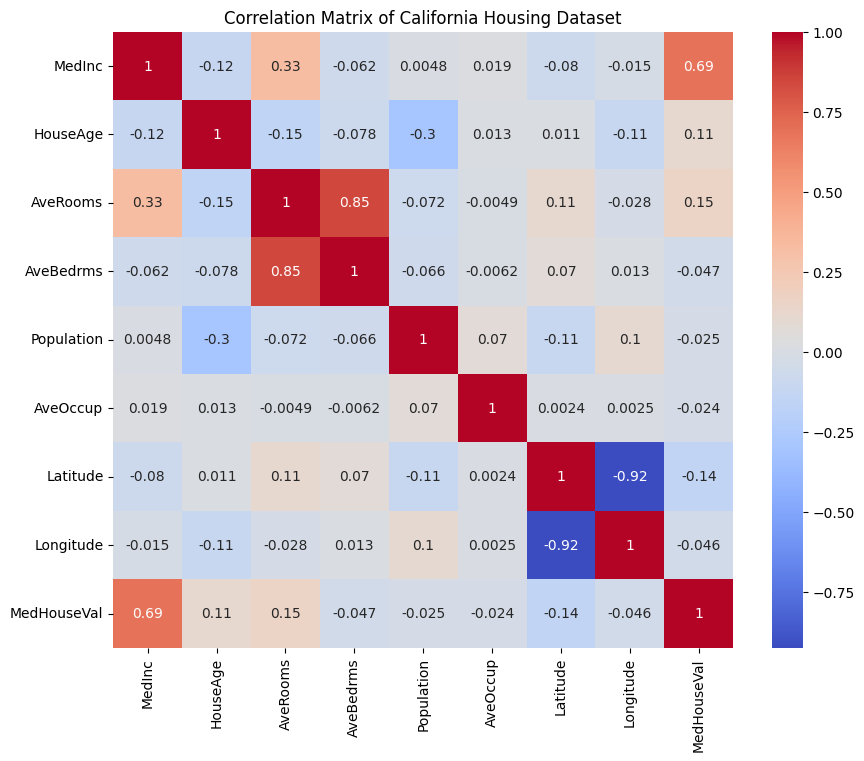

In [8]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of California Housing Dataset')
plt.show()



> The heatmap visualizes correlations between all features, highlighting which features are most strongly associated with house prices.



Pair plot of selected features

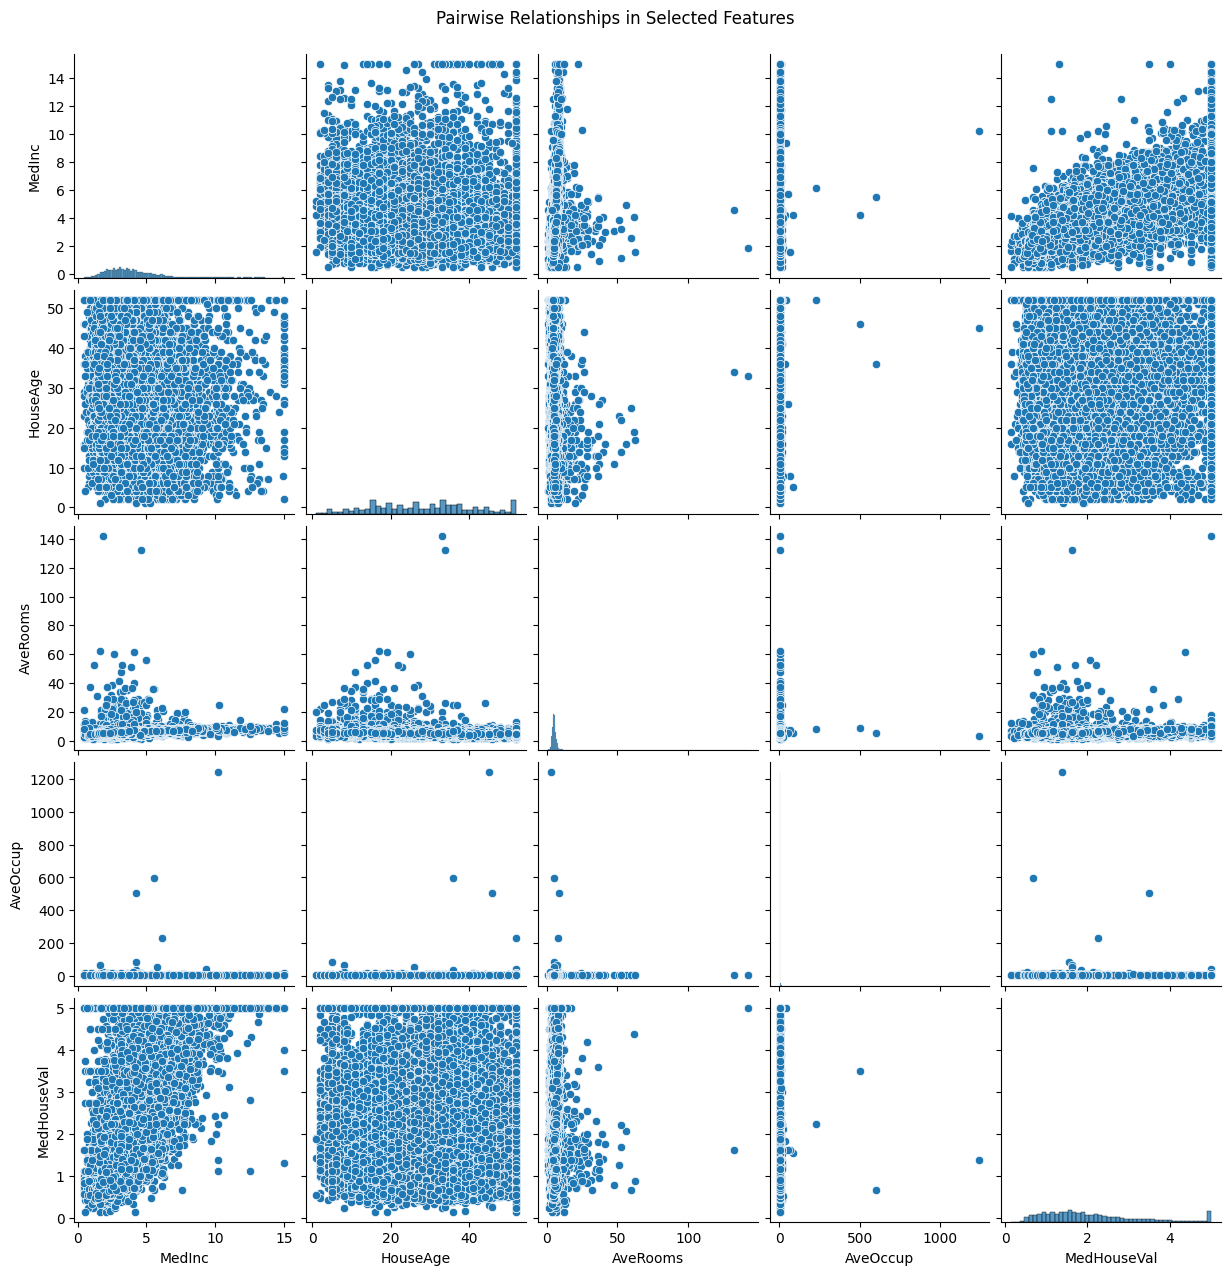

In [9]:
sns.pairplot(df[['MedInc', 'HouseAge', 'AveRooms', 'AveOccup', 'MedHouseVal']])
plt.suptitle("Pairwise Relationships in Selected Features", y=1.02)
plt.show()

>  A pair plot shows relationships between selected features, providing insights into how features are interrelated and how they relate to the target variable.

Distribution of House Age

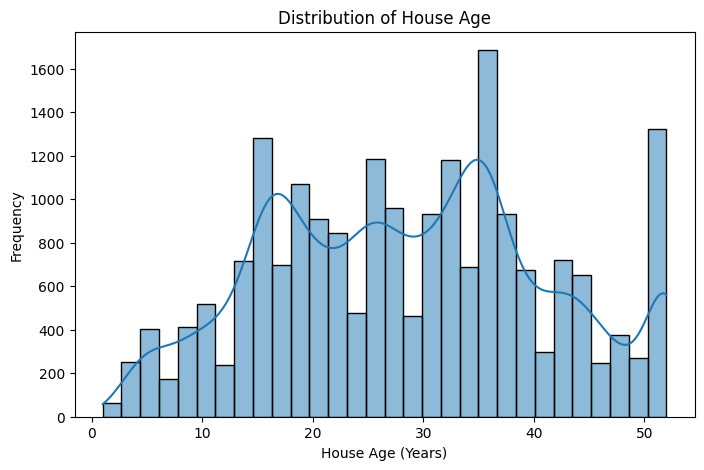

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(df['HouseAge'], bins=30, kde=True)
plt.title('Distribution of House Age')
plt.xlabel('House Age (Years)')
plt.ylabel('Frequency')
plt.show()

>  A histogram shows the distribution of house ages, highlighting the most common age range of houses in the dataset. This helps to understand the age demographics of the housing market.

Relationship Between Population and House Value

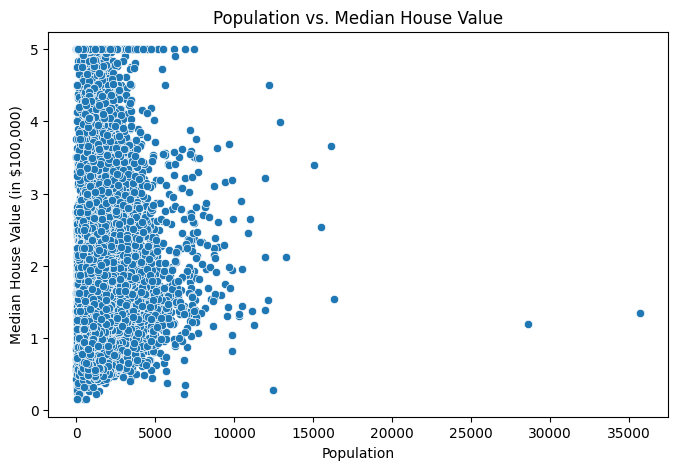

In [11]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Population', y='MedHouseVal', data=df)
plt.title('Population vs. Median House Value')
plt.xlabel('Population')
plt.ylabel('Median House Value (in $100,000)')
plt.show()

> A scatter plot shows how the population in a given area relates to house prices, which can reveal whether more populated areas tend to have higher or lower house values.

Average Number of Rooms vs. House Value

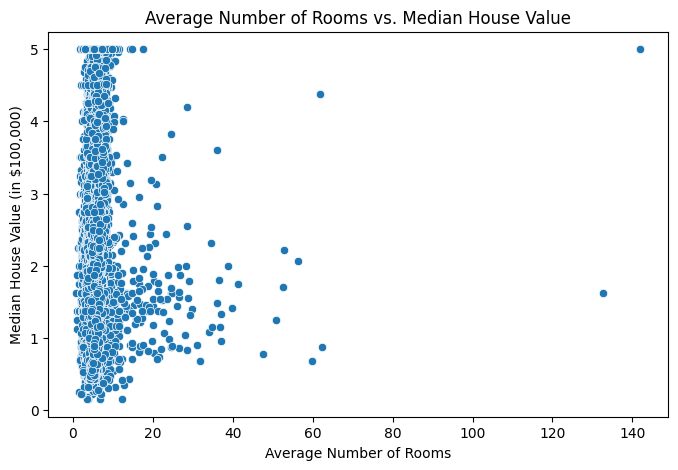

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='AveRooms', y='MedHouseVal', data=df)
plt.title('Average Number of Rooms vs. Median House Value')
plt.xlabel('Average Number of Rooms')
plt.ylabel('Median House Value (in $100,000)')
plt.show()



> This scatter plot helps to visualize the relationship between the average number of rooms in a house and its median value, showing whether more rooms correlate with higher prices.



House Value by Proximity to the Ocean

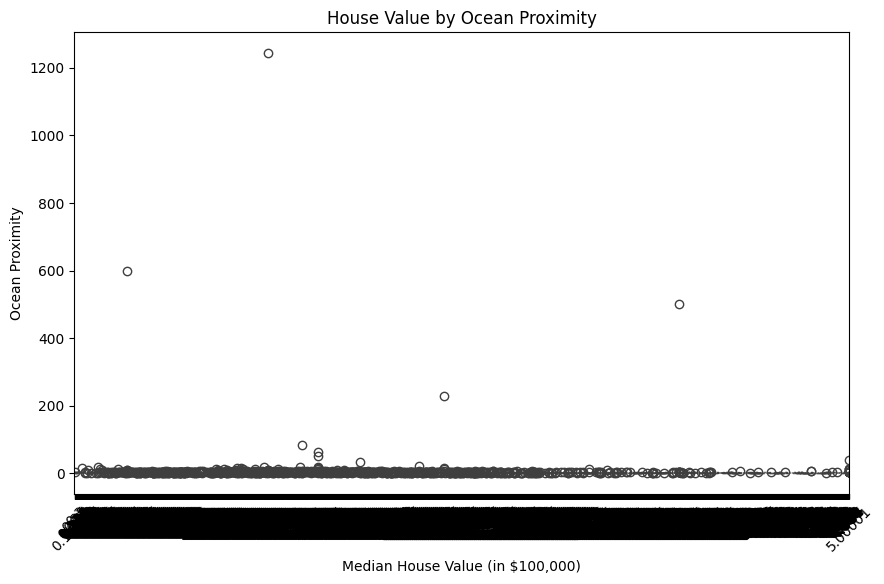

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['MedHouseVal'], y=df['AveOccup'])
plt.title('House Value by Ocean Proximity')
plt.xlabel('Median House Value (in $100,000)')
plt.ylabel('Ocean Proximity')
plt.xticks(rotation=45)
plt.show()

>This box plot shows the distribution of house values based on their proximity to the ocean, highlighting the impact of location (especially coastal proximity) on real estate prices.

Density Plot for Total Number of Rooms

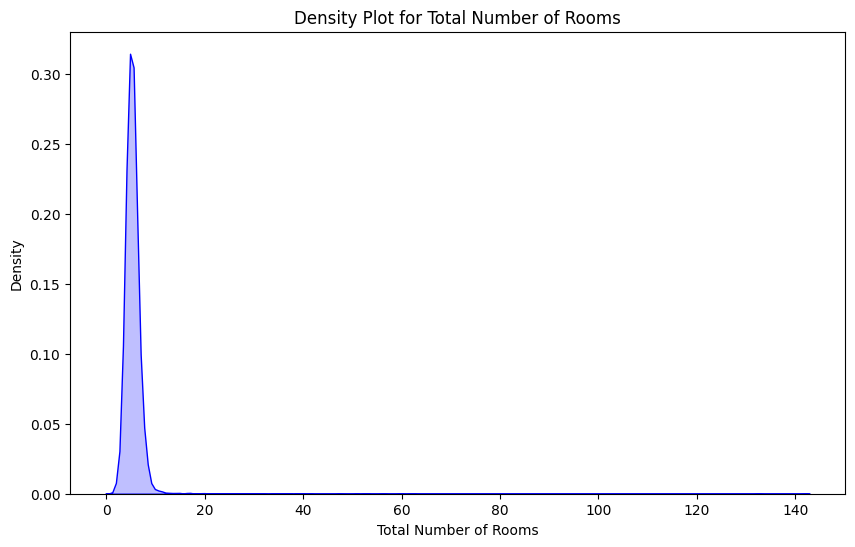

In [14]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='AveRooms', fill=True, color='blue')
plt.title('Density Plot for Total Number of Rooms')
plt.xlabel('Total Number of Rooms')
plt.ylabel('Density')
plt.show()

> A KDE plot shows the density distribution of the total number of rooms across all houses, providing insights into typical housing sizes and any potential skew in room count.

Relationship Between Median Income and House Age

<Figure size 800x500 with 0 Axes>

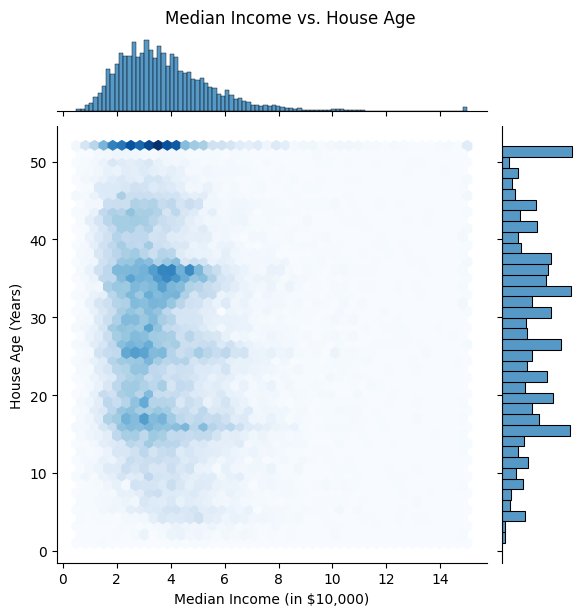

In [15]:
plt.figure(figsize=(8, 5))
sns.jointplot(x='MedInc', y='HouseAge', data=df, kind='hex', cmap='Blues')
plt.suptitle('Median Income vs. House Age', y=1.02)
plt.xlabel('Median Income (in $10,000)')
plt.ylabel('House Age (Years)')
plt.show()

> A joint plot shows the relationship between median income and house age, revealing patterns such as whether newer houses are built in higher-income areas.

## Feature Engineering

In [16]:
df['RoomsPerHousehold'] = df['AveRooms'] / df['AveOccup']
df['BedroomsPerRoom'] = df['AveBedrms'] / df['AveRooms']
df['PopulationPerHousehold'] = df['Population'] / df['AveOccup']


## KDE plot of house age distribution

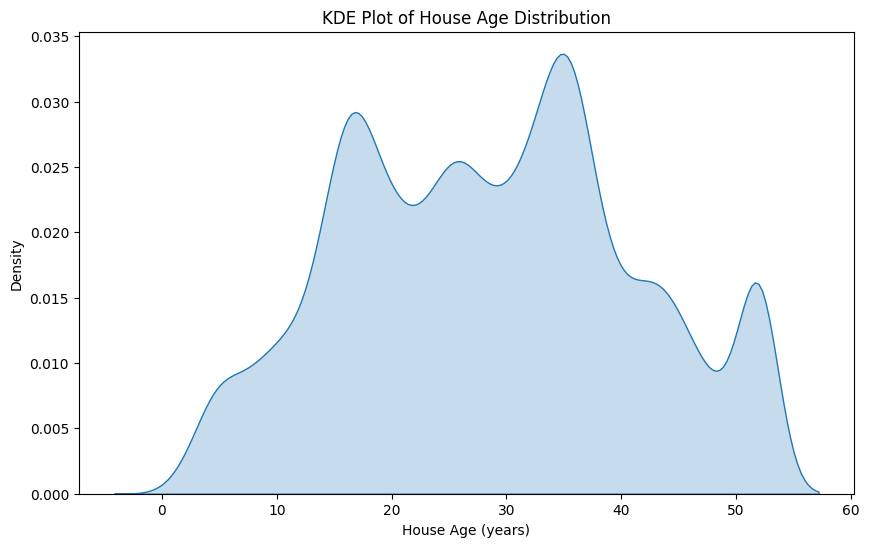

In [17]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df, x='HouseAge', fill=True)
plt.title('KDE Plot of House Age Distribution')
plt.xlabel('House Age (years)')
plt.ylabel('Density')
plt.show()

# Train-Test Split

In [18]:
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


## Feature Scaling

In [19]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Scaling + Encoding

In [1]:
numeric_features = X.select_dtypes(include=['float64']).columns
categorical_features = ['Location_Category']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

NameError: name 'X' is not defined

# Linear Regression

In [20]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MSE): {mse:.2f}")
print(f"R-squared (R2) score: {r2:.2f}")


Mean Squared Error (MSE): 0.45
Mean Absolute Error (MSE): 0.45
R-squared (R2) score: 0.65
